# realESRGAN
This Super Resolution model was trained in order to overcome the limited resources available for training the heavy GAN models. In fact it resulted very difficult to train GANs at high resolutions (1024x1024 or 512x512), either resulting in out of memory issues for the GPUs or mode collapse due to small training batches. This model ensured optimal GAN training for the generation of 256x256 low resolution images and successive high fidelity upscaling to 512x512. 

# IMPORTS

Imports necessary for the training of the real-ESRGAN SR model
- Datasets in 256x256, 512x512, both pre-processed in the same way it was done in the StyleGAN2-ADA preprocessing pipeline
- Real-ESRGAN repo and pretrained model RealESRGAN_x2plus

And some patches for compatibility issues between kaggle versions and model versions of the libraries

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
import torchvision
import torch

## Path Setup
%cd /kaggle/working/

# Import and download datasets
!pip install gdown
!gdown --folder https://drive.google.com/drive/u/0/folders/1evz7oIx4_y962qds6SsAiJ0Swa53n9pV -O ./data/ #path to download datasets


# FIX to BasicSR
if not hasattr(torchvision.transforms, 'functional_tensor'):
    import torchvision.transforms.functional as F
    torchvision.transforms.functional_tensor = F
    print("Fix applicato: torchvision.transforms.functional_tensor indirizzato a functional.")

# Git Clone of the Real-ESRGAN repo and of the pretrained model
!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN
!pip install basicsr facexlib gfpgan
!pip install -r requirements.txt
!python setup.py develop

# pretrained weights download (x2 finetuning) 
!wget https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.1/RealESRGAN_x2plus.pth -P experiments/pretrained_models


In [ ]:

!pip install addict
!pip install future
!pip install yapf

import os

# Patch for the degradation.py file
path = '/usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py'
if os.path.exists(path):
    !sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/' {path}
    print("Patch 1 ready")

#Patch for the lr_scheduler.py  file
path_lr = '/usr/local/lib/python3.12/dist-packages/basicsr/utils/lr_scheduler.py'
if os.path.exists(path_lr):
    !sed -i 's/from torch._six import container_abcs/import collections.abc as container_abcs/' {path_lr}
    print("Patch 2 ready")


# DATASET PREPROCESSING AND TRAINING PREP

There is not much data pre-processing since the dataset have been already pre-processed in the StyleGAN-ADA2 pipeline, most of the code is aimed at verifying if the two datasets are correctly matched and eliminate discontinuities. Furthermore it creates a number of files necessary for training such as the meta_info and yaml files.

In [ ]:
import os
import shutil
from tqdm import tqdm
from pathlib import Path
import zipfile

## Path Setup
%cd /kaggle/working/

#datasets in 256 and 512 necessary for upscaling training
BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / 'data' / 'Real-ESRGAN-dataset'


train_hr_dir = '/kaggle/working/train_HR'
train_lr_dir = '/kaggle/working/train_LR'

os.makedirs(train_hr_dir, exist_ok=True)
os.makedirs(train_lr_dir, exist_ok=True)

## ZIP Decompression
zip_paths = {
    "ALL_RGB_256Q": DATA_DIR / 'ALL_RGB_256Q.zip',
    "ALL_RGB_512Q": DATA_DIR / 'ALL_RGB_512Q.zip'
}

print("Compressed folders unzipping")
for name, path_zip in zip_paths.items():
    if path_zip.exists():
        extract_dir = DATA_DIR / name
        print(f"Estrazione di {name} in {extract_dir}...")
        
        with zipfile.ZipFile(path_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
            
        path_zip.unlink()
        
    else:
        print(f"WARNING: ZIP FILE NOT FOUND -> {path_zip}")


print("\nVerifying images...")


base_256 = DATA_DIR / "ALL_RGB_256Q"
base_512 = DATA_DIR / "ALL_RGB_512Q"

images_512 = [f for f in base_512.rglob('*') if f.suffix.lower() in ['.png', '.jpg', '.jpeg']]
images_256 = {f.name: f for f in base_256.rglob('*') if f.suffix.lower() in ['.png', '.jpg', '.jpeg']}

if images_512:
    for img_512_path in tqdm(images_512):
        img_name = img_512_path.name
        # Copy HR (512)
        shutil.copy(img_512_path, os.path.join(train_hr_dir, img_name))
        # Copy LR (256)
        if img_name in images_256:
            shutil.copy(images_256[img_name], os.path.join(train_lr_dir, img_name))

# meta-info.txt generation
with open('/kaggle/working/meta_info.txt', 'w') as f:
    for img_name in sorted(os.listdir(train_hr_dir)):
        if img_name != 'meta_info.txt':
            f.write(f"{img_name} (512, 512, 3)\n")

print("Dataset ready")

In [ ]:
#YAML file generation, it contains the training info
%cd Real-ESRGAN
yaml_content = """
name: Orto_SR_FineTuning_x2_NewStart
model_type: SRGANModel
scale: 2
num_gpu: 2
manual_seed: 0

datasets:
  train:
    name: OrtoDataset_Train
    type: PairedImageDataset
    dataroot_gt: /kaggle/working/train_HR
    dataroot_lq: /kaggle/working/train_LR
    meta_info: /kaggle/working/train_HR/meta_info.txt
    io_backend:
      type: disk
    gt_size: 256
    use_hflip: true
    use_rot: false
    num_worker_per_gpu: 4
    batch_size_per_gpu: 8
    dataset_enlarge_ratio: 1
    prefetch_mode: ~

  val:
    name: Val_5_Immagini
    type: PairedImageDataset
    dataroot_gt: /kaggle/working/dataset/val_1024
    dataroot_lq: /kaggle/working/dataset/val_256
    io_backend:
      type: disk

network_g:
  type: RRDBNet
  num_in_ch: 3
  num_out_ch: 3
  num_feat: 64
  num_block: 23
  num_grow_ch: 32
  scale: 2

network_d:
  type: UNetDiscriminatorSN
  num_in_ch: 3
  num_feat: 64
  skip_connection: true

path:
  pretrain_network_g: experiments/pretrained_models/RealESRGAN_x2plus.pth
  param_key_g: params_ema
  strict_load_g: true
  # COMMENTATO: Non carichiamo nessun vecchio checkpoint (.state)
  # resume_state: ~ 

train:
  ema_decay: 0.999
  optim_g:
    type: Adam
    lr: !!float 1e-4
    weight_decay: 0
    betas: [0.9, 0.99]
  optim_d:
    type: Adam
    lr: !!float 1e-4
    weight_decay: 0
    betas: [0.9, 0.99]
  
  scheduler:
    type: MultiStepLR
    milestones: [10000, 20000, 30000]
    gamma: 0.5

  total_iter: 40000
  warmup_iter: -1 
  pixel_opt:
    type: L1Loss
    loss_weight: 5.0   
    reduction: mean
  perceptual_opt:
    type: PerceptualLoss
    layer_weights:
      'conv5_4': 1
    vgg_type: vgg19
    use_input_norm: true
    perceptual_weight: 1.0
    style_weight: 0
    range_norm: false
    criterion: l1
  gan_opt:
    type: GANLoss
    gan_type: vanilla
    real_label_val: 1.0
    fake_label_val: 0.0
    loss_weight: !!float 5e-2  

val:
  val_freq: !!float 5000
  save_img: false
  metrics:
    psnr:
      type: calculate_psnr
      crop_border: 2
      test_y_channel: false

logger:
  print_freq: 100
  save_checkpoint_freq: !!float 5000
  visual_freq: !!float 1000
  use_tb_logger: true
"""

with open('options/train_orto_sr.yml', 'w') as f:
    f.write(yaml_content)

print("YAML ready")

In [ ]:
import os
import shutil
from pathlib import Path

# High res and Low res datasets PATHS
base_path = Path('/kaggle/working')
train_hr_dir = base_path / 'train_HR'
train_lr_dir = base_path / 'train_LR'

# Validation directories
val_hr_dir = base_path / 'dataset/val_1024' 
val_lr_dir = base_path / 'dataset/val_256'

# we extract meta_info from the image directory
meta_info_path = train_hr_dir / 'meta_info.txt'
if meta_info_path.exists():
    meta_info_path.rename(base_path / 'meta_info.txt')

# Scrubbing of the image directories of excess files
def scrub_directory(directory):
    for item in directory.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
            print(f"excess directory eliminated: {item.name}")
        elif item.suffix.lower() not in ['.png', '.jpg', '.jpeg']:
            item.unlink()
            print(f"excess file eliminated: {item.name}")

scrub_directory(train_hr_dir)
scrub_directory(train_lr_dir)

# Making sure that the two HR and LR files are synchronized
hr_files = {f.stem: f for f in train_hr_dir.glob('*') if f.is_file()}
lr_files = {f.stem: f for f in train_lr_dir.glob('*') if f.is_file()}

# Unmatched images are found and eliminated
solo_in_hr = set(hr_files.keys()) - set(lr_files.keys())
solo_in_lr = set(lr_files.keys()) - set(hr_files.keys())

for nome in solo_in_hr:
    hr_files[nome].unlink()
    print(f"excess image eliminated for HR {hr_files[nome].name}")

for nome in solo_in_lr:
    lr_files[nome].unlink()
    print(f"excess image eliminated from LR {lr_files[nome].name}")

print(f"\nThe dataset is balanced HR: {len(list(train_hr_dir.glob('*')))} | LR: {len(list(train_lr_dir.glob('*')))}")

#Validation Directory creation
val_hr_dir.mkdir(parents=True, exist_ok=True)
val_lr_dir.mkdir(parents=True, exist_ok=True)

# we take 5 images from HR
immagini_val = sorted(train_hr_dir.glob('*'))[:5]

for hr_img in immagini_val:
    # and find its match in LR
    lr_img = train_lr_dir / (hr_img.stem + next(train_lr_dir.glob(f"{hr_img.stem}.*")).suffix)
    
    shutil.move(str(hr_img), str(val_hr_dir / hr_img.name))
    shutil.move(str(lr_img), str(val_lr_dir / lr_img.name))

print("\nEverything is setup for training")

# TRAINING

In [ ]:
!torchrun --nproc_per_node=2 --master_port=4321 \
    realesrgan/train.py -opt options/train_orto_sr.yml --launcher pytorch

# REAL IMAGE 256x256 -> 512x512
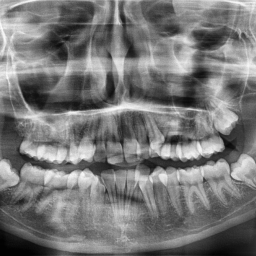
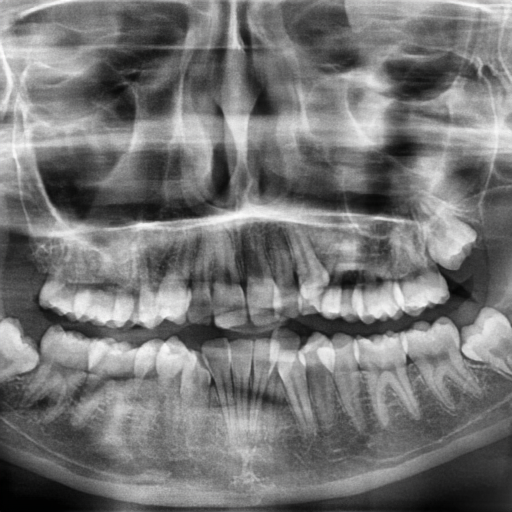


# STYLEGAN2-ADA 256x256 -> 512x512
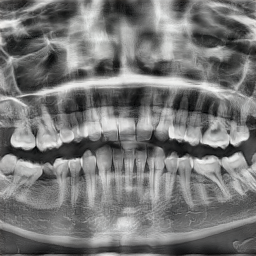
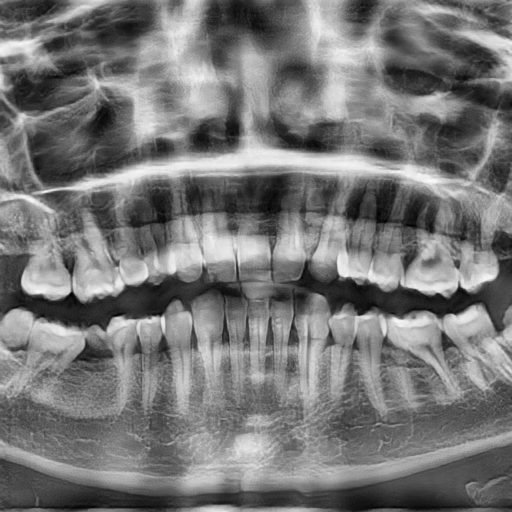
